# **Always run in colab, not in cursor, vs code etc..**

In [ ]:
# general installation to avoid version related errors

!pip install -q --upgrade datasets==3.6.0 transformers==4.57.6 huggingface_hub diffusers

In [ ]:
# Import + Hugging model setup statements

from transformers import pipeline
from diffusers import AutoPipelineForText2Image

from IPython.display import Audio, display

from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset
import torch

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
# Text model download - always keep it minimal for testing purpose - check how to reduce the time that takes to load the components and check for deploy as well

pipe_text = pipeline("text-generation", model="google/gemma-2-2b-it")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


In [ ]:
# Using text based model with our own input

response = pipe_text("Explain how carrot looks like in 2 sentences")
generated_text = response[0]['generated_text']
print(generated_text)

Explain how carrot looks like in 2 sentences.

A carrot is a root vegetable with a long, cylindrical shape. It typically features a bright orange color that can vary in intensity depending on the variety. 



In [ ]:
# Audio is not important, I just created it simplyto check whether it is working

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='cuda')
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)


Device set to use cuda


In [ ]:
# using that speech model

speech = synthesiser(generated_text, forward_params={"speaker_embeddings": speaker_embedding})

Audio(speech["audio"], rate=speech["sampling_rate"])

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


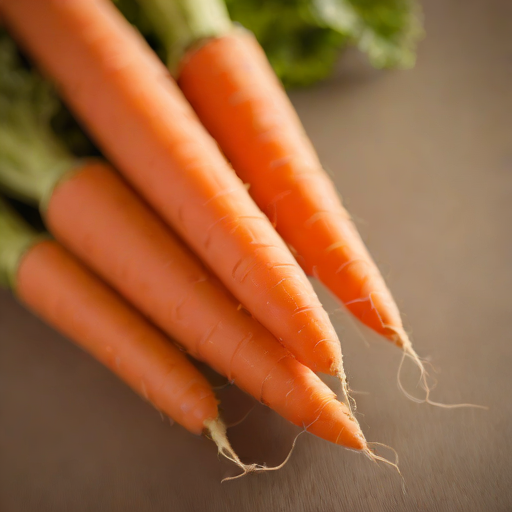

In [ ]:
# Image model initiallisation from diffusion and not transformers

pipe_image = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", dtype=torch.float16, variant="fp16")
pipe_image.to("cuda")


In [ ]:
# Using that iamge module in here

image = pipe_image(prompt=generated_text, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)